In [ ]:
!pip install ydata-profiling sweetviz autoviz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.7 MB/s eta 0:00:00


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  ШАГ 2: Импорт библиотек и генерация датасета           ║
# ╚══════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np

# Создаём синтетический банковский датасет (как в прошлых уроках)
np.random.seed(42)
N = 2000
cities = ['Москва', 'Санкт-Петербург', 'Казань', 'Новосибирск', 'Екатеринбург']
names = ['Иван', 'Ольга', 'Дмитрий', 'Екатерина', 'Сергей', 'Анна', 'Алексей', 'Мария']

df = pd.DataFrame({
    'client_id': range(1001, 1001 + N),
    'name': np.random.choice(names, N),
    'city': np.random.choice(cities, N),
    'age': np.random.randint(21, 70, N),
    'income': np.random.normal(50000, 20000, N).astype(int),
    'loan_amount': np.random.normal(200000, 80000, N).astype(int),
    'credit_score': np.random.normal(650, 100, N).astype(int),
    'default': np.random.choice([0, 1], N, p=[0.9, 0.1])
})

# Добавим несколько аномалий
df.loc[0, 'income'] = 500000
df.loc[1, 'loan_amount'] = 1000000
df.loc[2, 'age'] = 18

df['income'] = df['income'].clip(lower=0)
df['loan_amount'] = df['loan_amount'].clip(lower=0)

print(f"Датасет: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

Датасет: 2000 строк, 8 колонок


,client_id,name,city,age,income,loan_amount,credit_score,default
0,1001,Алексей,Новосибирск,56,500000,224515,682,0
1,1002,Екатерина,Казань,28,48287,1000000,755,0
2,1003,Сергей,Екатеринбург,18,80152,144570,605,0
3,1004,Алексей,Москва,52,36156,195643,717,0
4,1005,Дмитрий,Екатеринбург,34,76160,165023,371,0


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1kwXVHdRapfFd2EK5-rnnUsf1jKp9-3bOYh8POWCNDL4/edit#gid=0


## YData Profiling — полный отчёт одной строкой

YData Profiling (раньше назывался Pandas Profiling) создаёт HTML-отчёт, который содержит:
- Статистики по каждой колонке
- Гистограммы
- Корреляционную матрицу
- Список предупреждений (например, "колонка имеет 60% пропусков")

In [ ]:
#  Генерация отчёта YData Profiling
#   ProfileReport(df, title="...") — создаёт объект отчёта
#   .to_file("имя.html") — сохраняет отчёт как HTML
#   В Colab можно открыть HTML через файловый менеджер

from ydata_profiling import ProfileReport

report = ProfileReport(df, title="Отчёт по клиентам банка")
report.to_file("bank_report.html")
print("Отчёт сохранён как bank_report.html")
print("Скачай его в панели файлов слева и открой в браузере.")

/tmp/ipykernel_9610/703361848.py:6: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 39.55it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Отчёт сохранён как bank_report.html
Скачай его в панели файлов слева и открой в браузере.


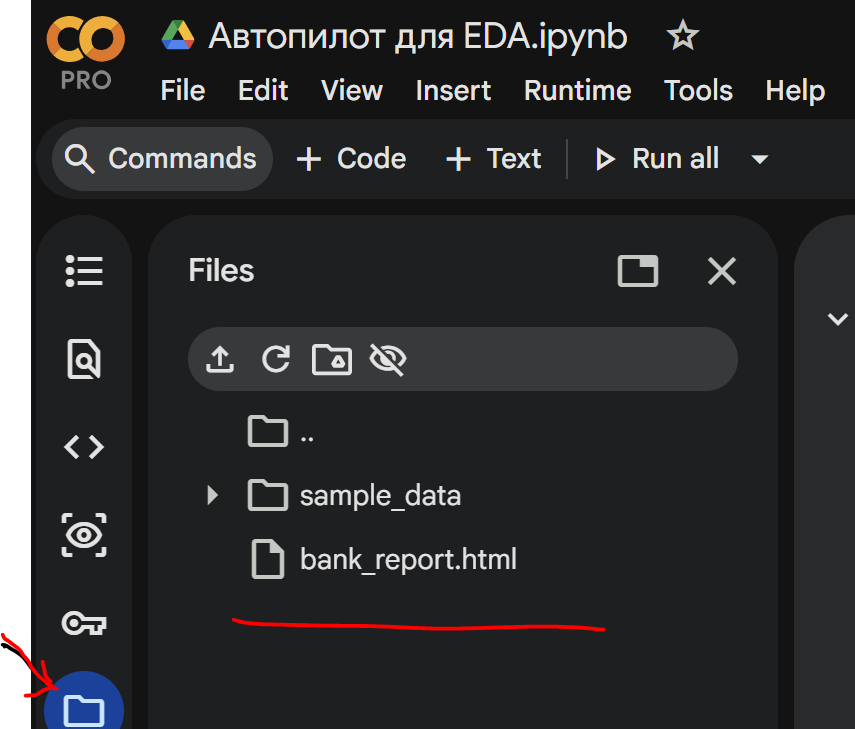

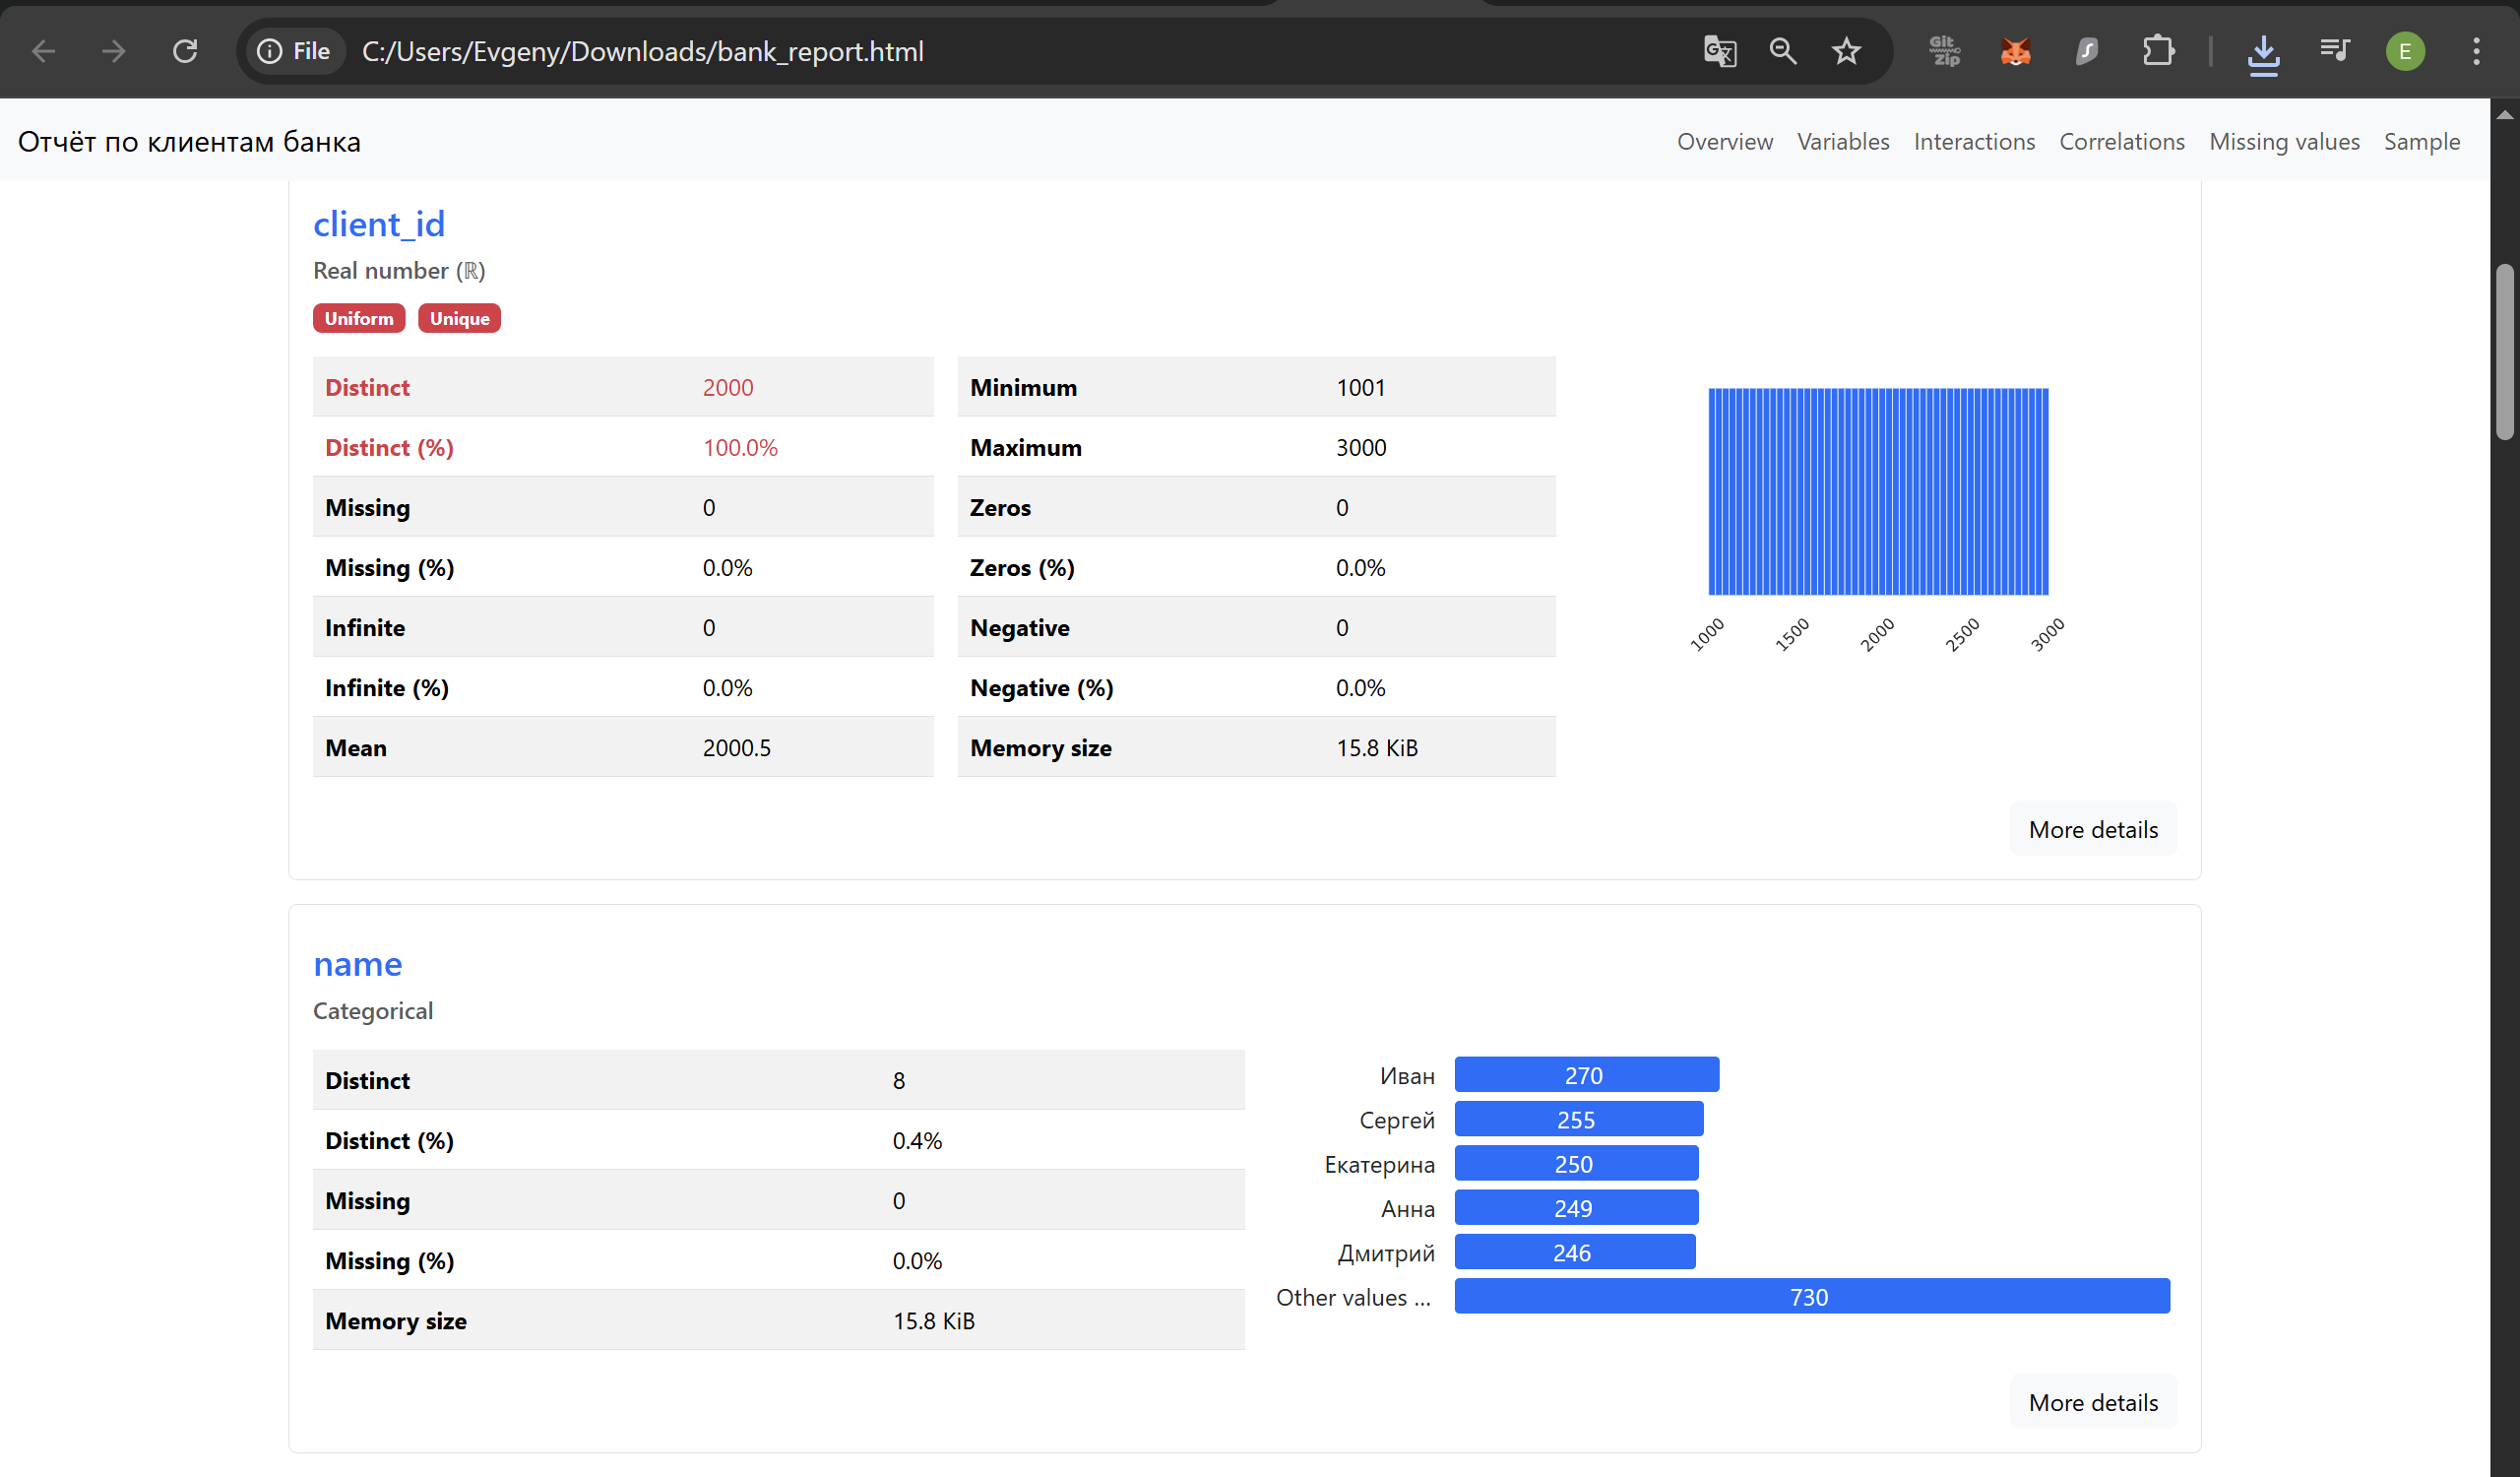

**Как интерпретировать отчёт:**
- **Overview** — общая информация: размер, число пропусков, типы колонок
- **Variables** — по каждой колонке: гистограмма, минимум/максимум/среднее, доля уникальных значений
- **Correlations** — тепловая карта корреляций (как sns.heatmap, но интерактивная)
- **Alerts** — система предупреждает, если в данных проблемы (например, константная колонка)

## 🍬 SweetViz — сравниваем плательщиков и дефолтников

SweetViz отлично подходит для сравнения двух выборок. Cравним клиентов с default=0 (плательщики) и default=1 (дефолтники).

In [ ]:
# Отчёт SweetViz
# sv.compare(df1, df2) — сравнивает два DataFrame
# target_feat='default' — целевая переменная
# .show_html() — открывает отчёт в Colab (через iframe)

import sweetviz as sv

# Делим датасет на плательщиков и дефолтников
good = df[df['default'] == 0]  # те, кто платит
bad = df[df['default'] == 1]   # те, кто в дефолте

# Сравниваем
report_sv = sv.compare([good, "Плательщики"], [bad, "Дефолтники"], target_feat='default')
report_sv.show_html("sweetviz_report.html")
print("Отчёт SweetViz сохранён как sweetviz_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Отчёт SweetViz сохранён как sweetviz_report.html


**Как интерпретировать отчёт:**
- График для каждой переменной показывает распределение в двух группах
- Если распределения сильно различаются — переменная важна для прогноза дефолта
- Например, если у дефолтников income в среднем ниже — это хороший признак для модели

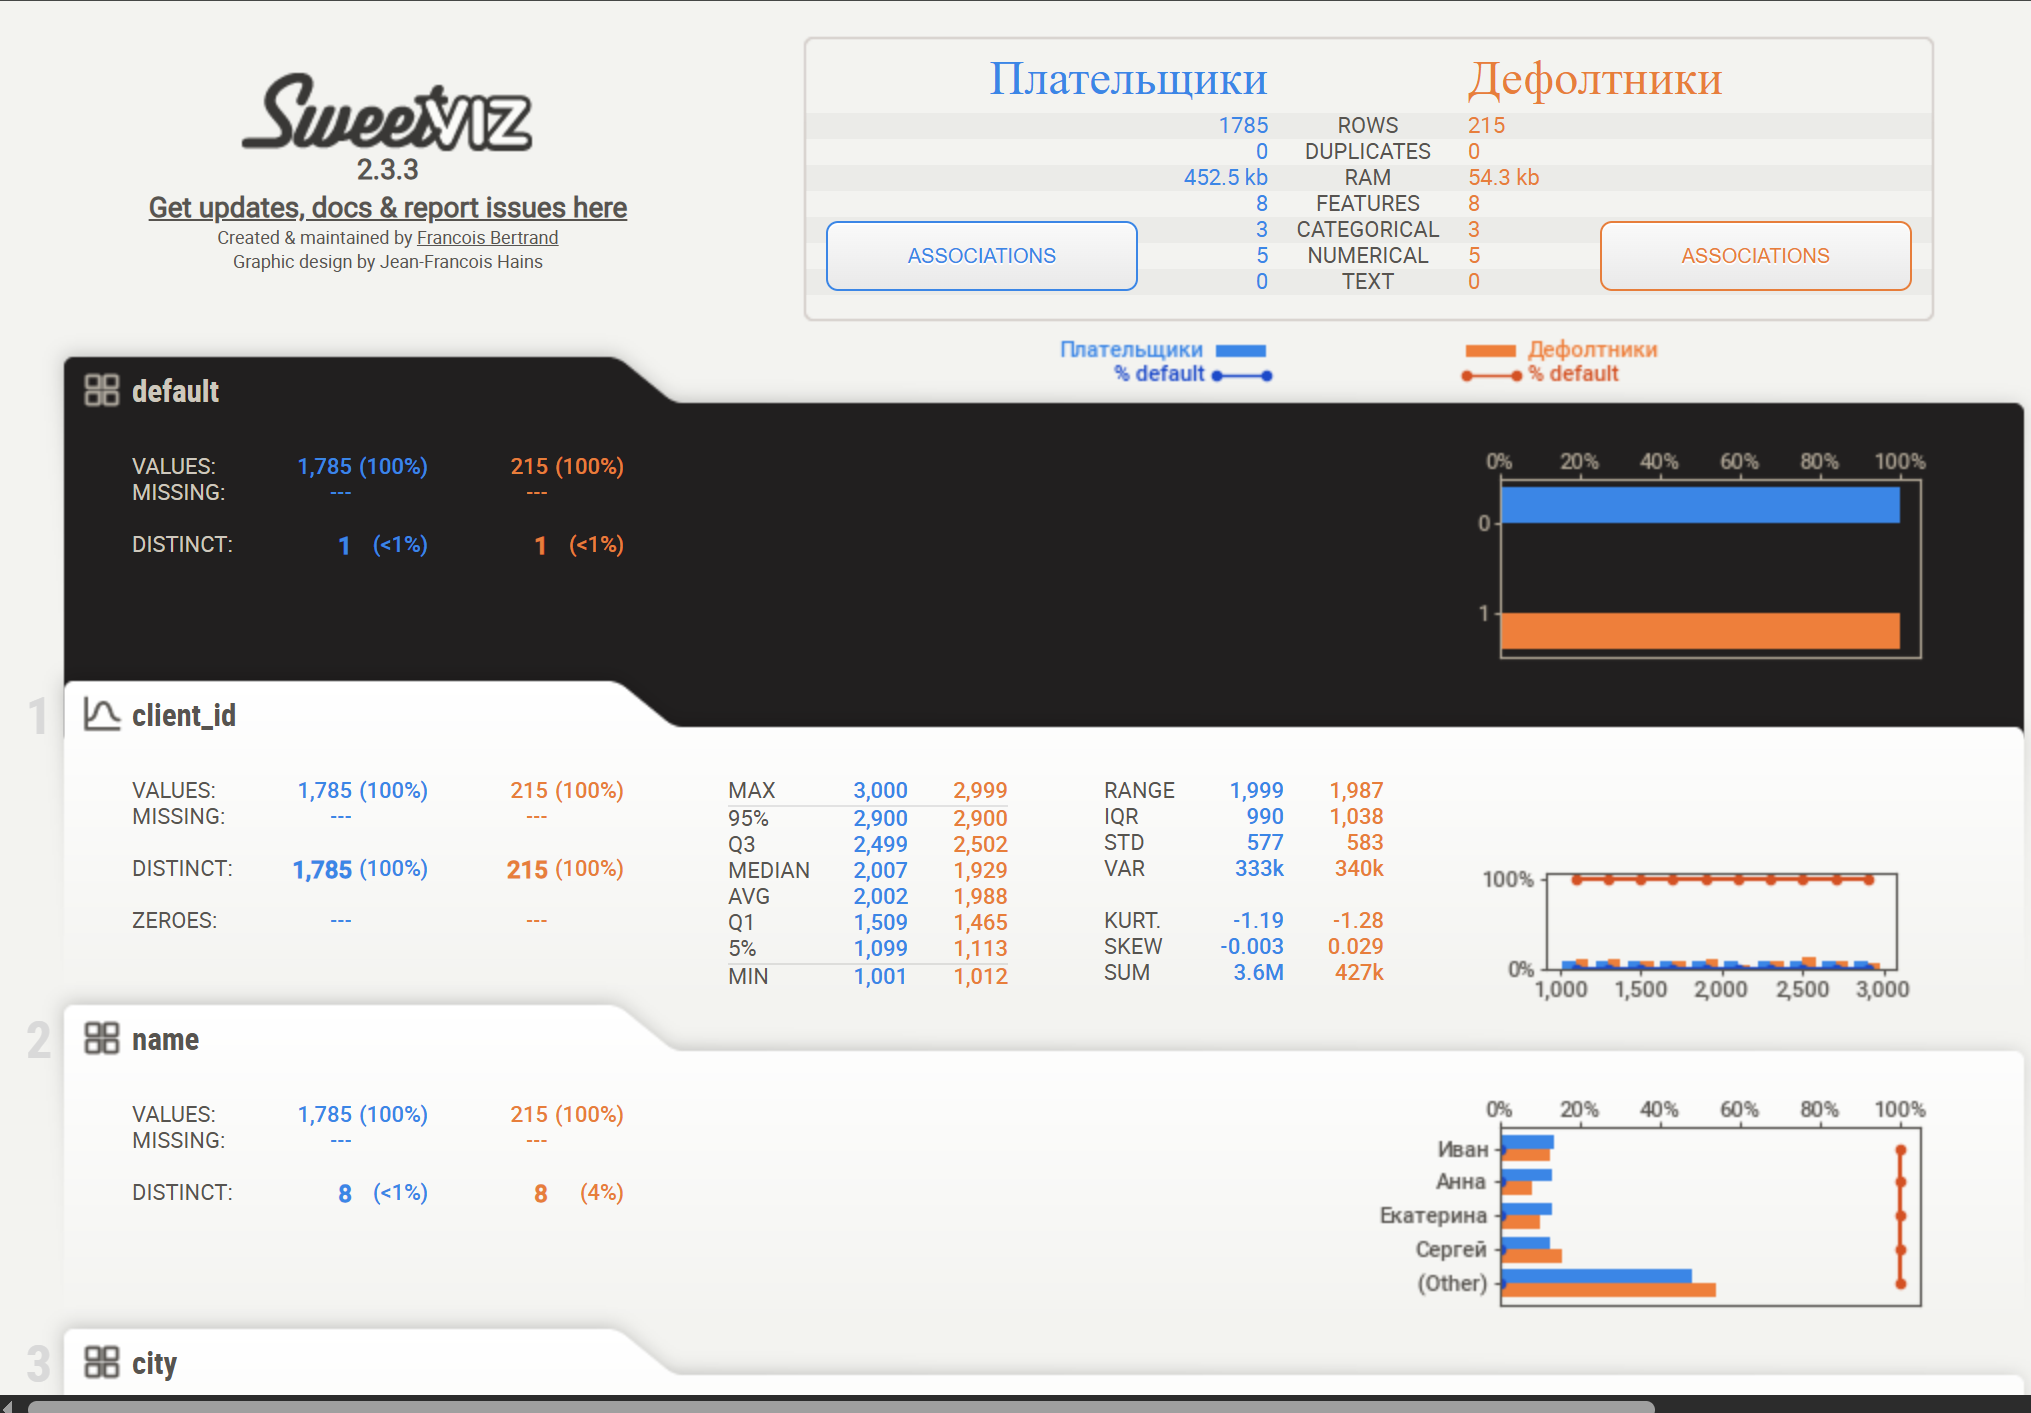

## AutoViz — автоматический подбор графиков

AutoViz сам решает, какие графики строить для каждой колонки. Особенно удобен для быстрой проверки гипотез.

In [ ]:

#   AutoViz_Class() — создаёт объект класса
#   AV.AutoViz(df, depVar='default') — строит все графики
#   chart_format='html' — для Colab лучше html

from autoviz import AutoViz_Class

AV = AutoViz_Class()
# verbose=1 показывает процесс, chart_format='html' отображает в Colab
df_viz = AV.AutoViz(df, depVar='default', verbose=1, chart_format='html')

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)
Shape of your Data Set loaded: (2000, 8)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  4
    Number of String-Categorical Columns =  2
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of 

Saving scatterplots in HTML format
  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:00<00:00,  7.14it/s]

 50%|█████     | 2/4 [00:00<00:00,  7.35it/s]

 75%|███████▌  | 3/4 [00:00<00:00,  7.32it/s]

...

Saving violinplots in HTML format


No date vars could be found in data set


Saving heatmaps in HTML format


Saving cat_var_plots in HTML format
                                               

Time to run AutoViz (in seconds) = 33


**Как интерпретировать результат:**
- AutoViz сам разделит признаки на числовые и категориальные
- Для каждого признака построит подходящий график (гистограмму, boxplot, scatter, heatmap)
- Если есть целевая переменная (depVar), покажет, как признаки с ней связаны

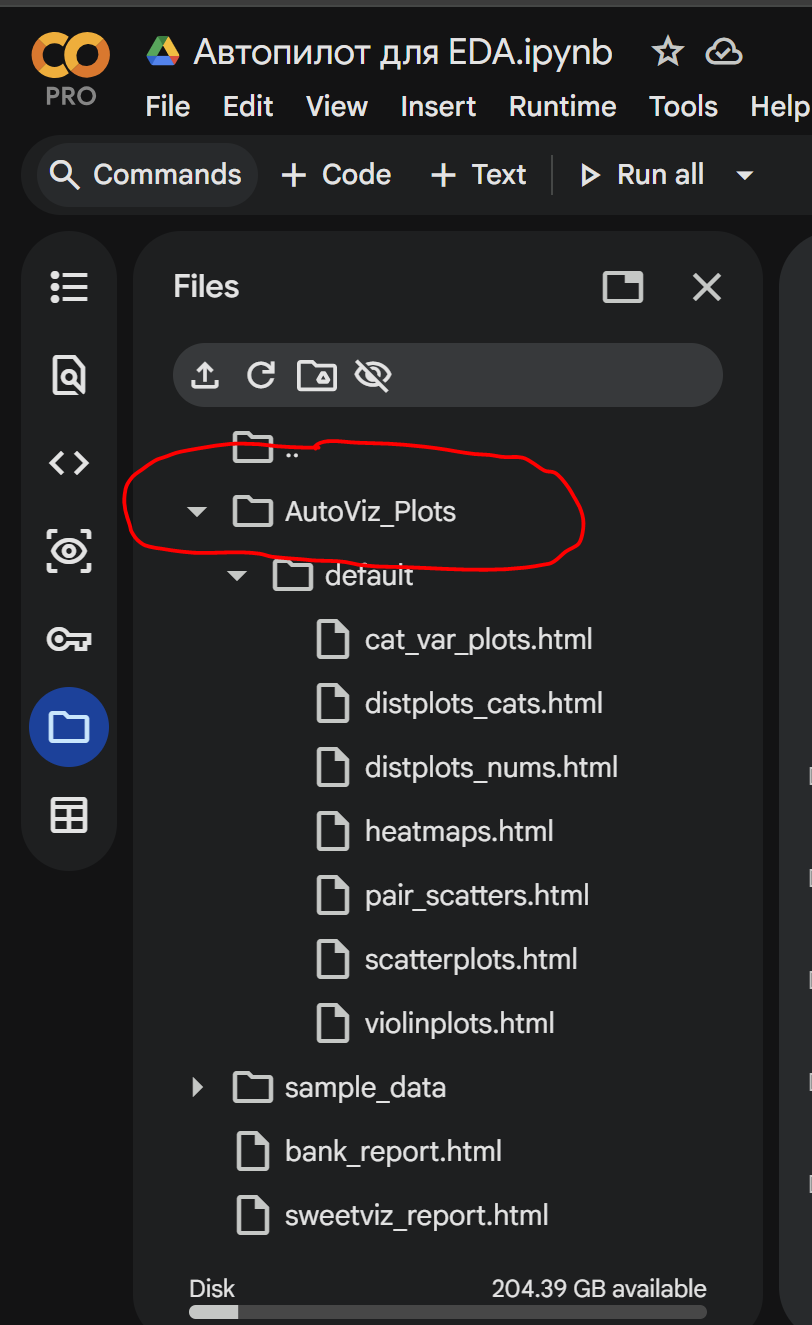

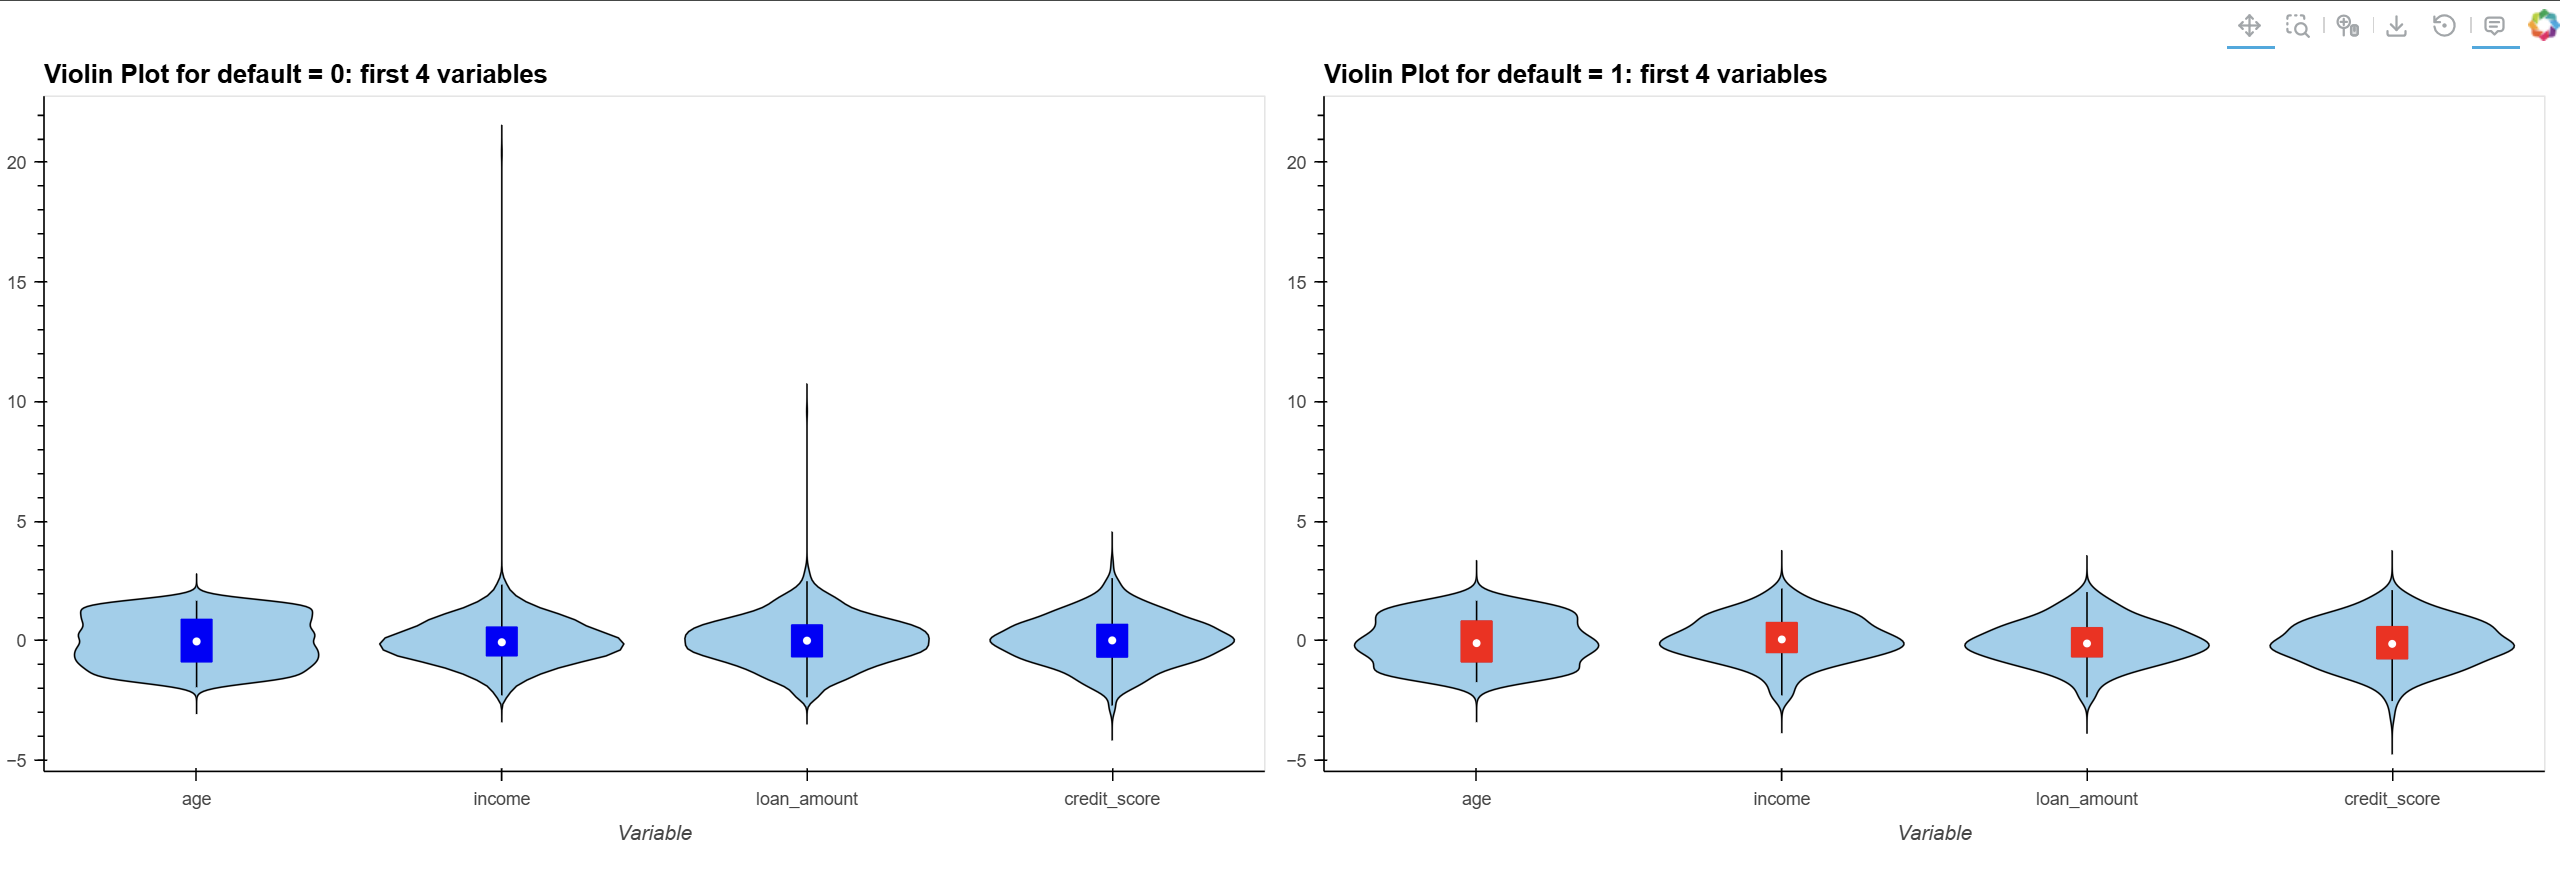

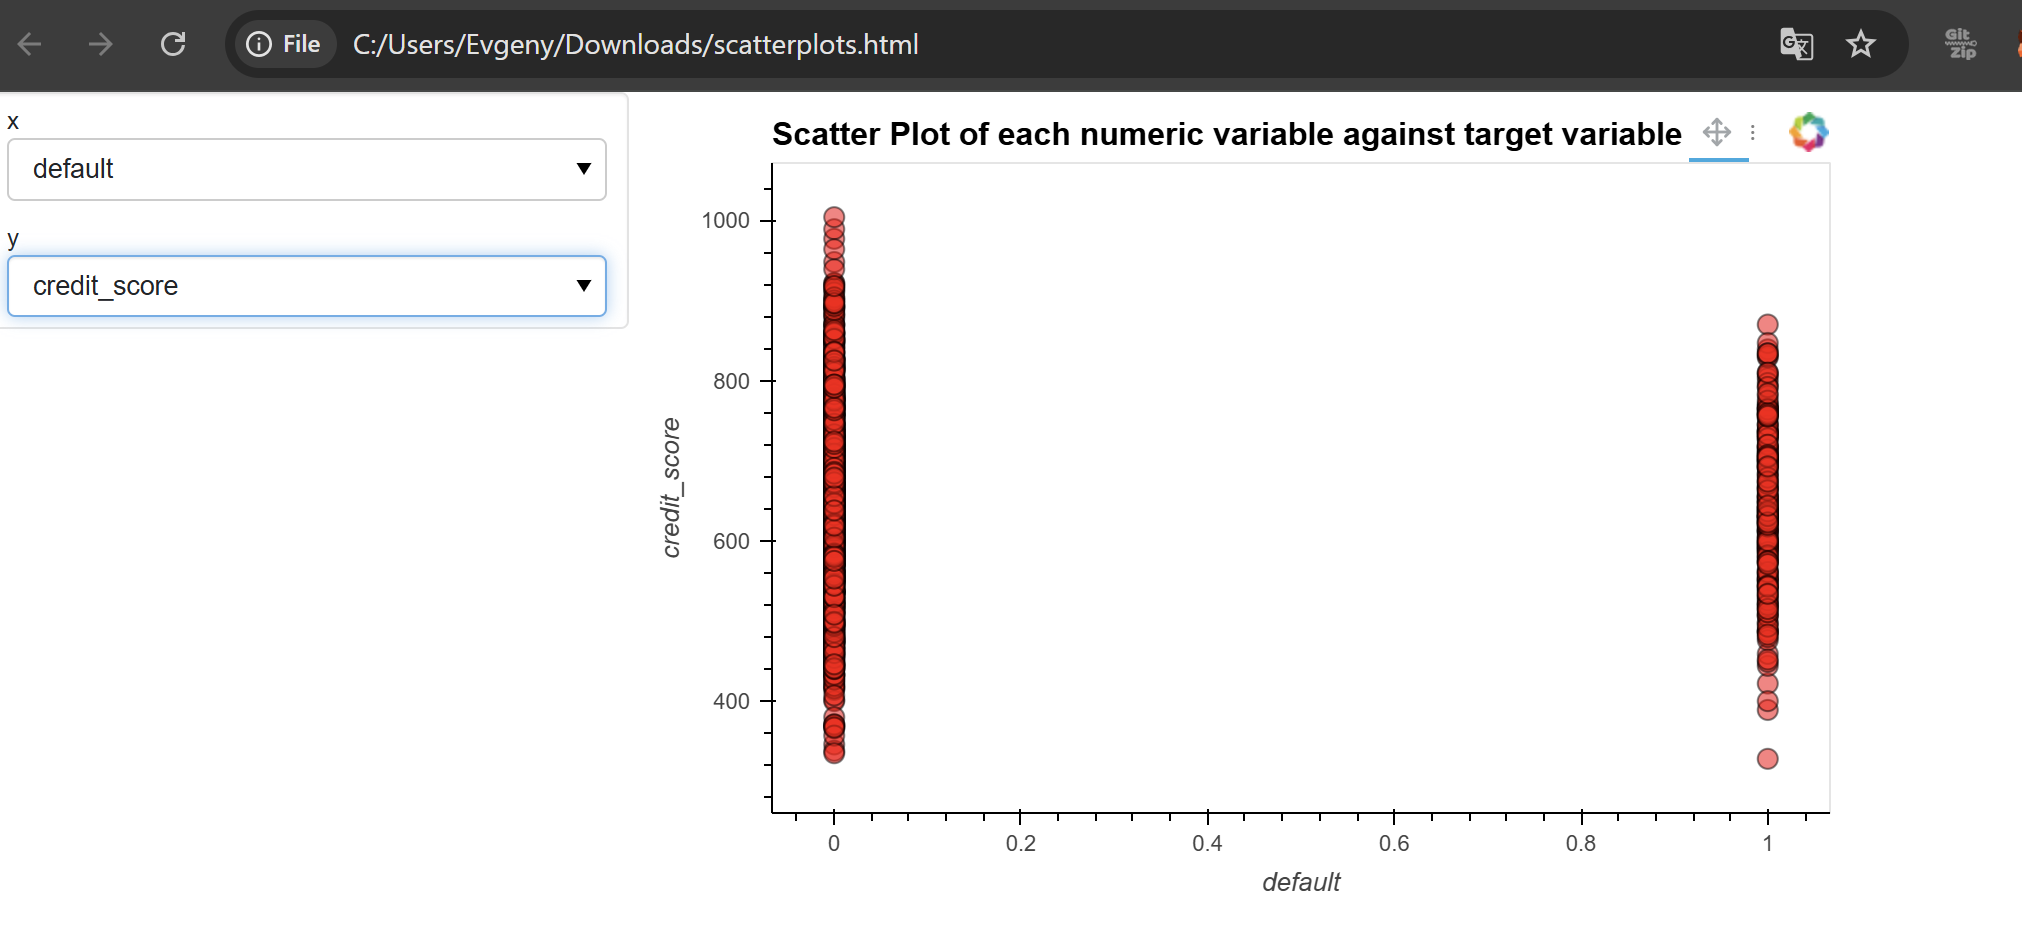

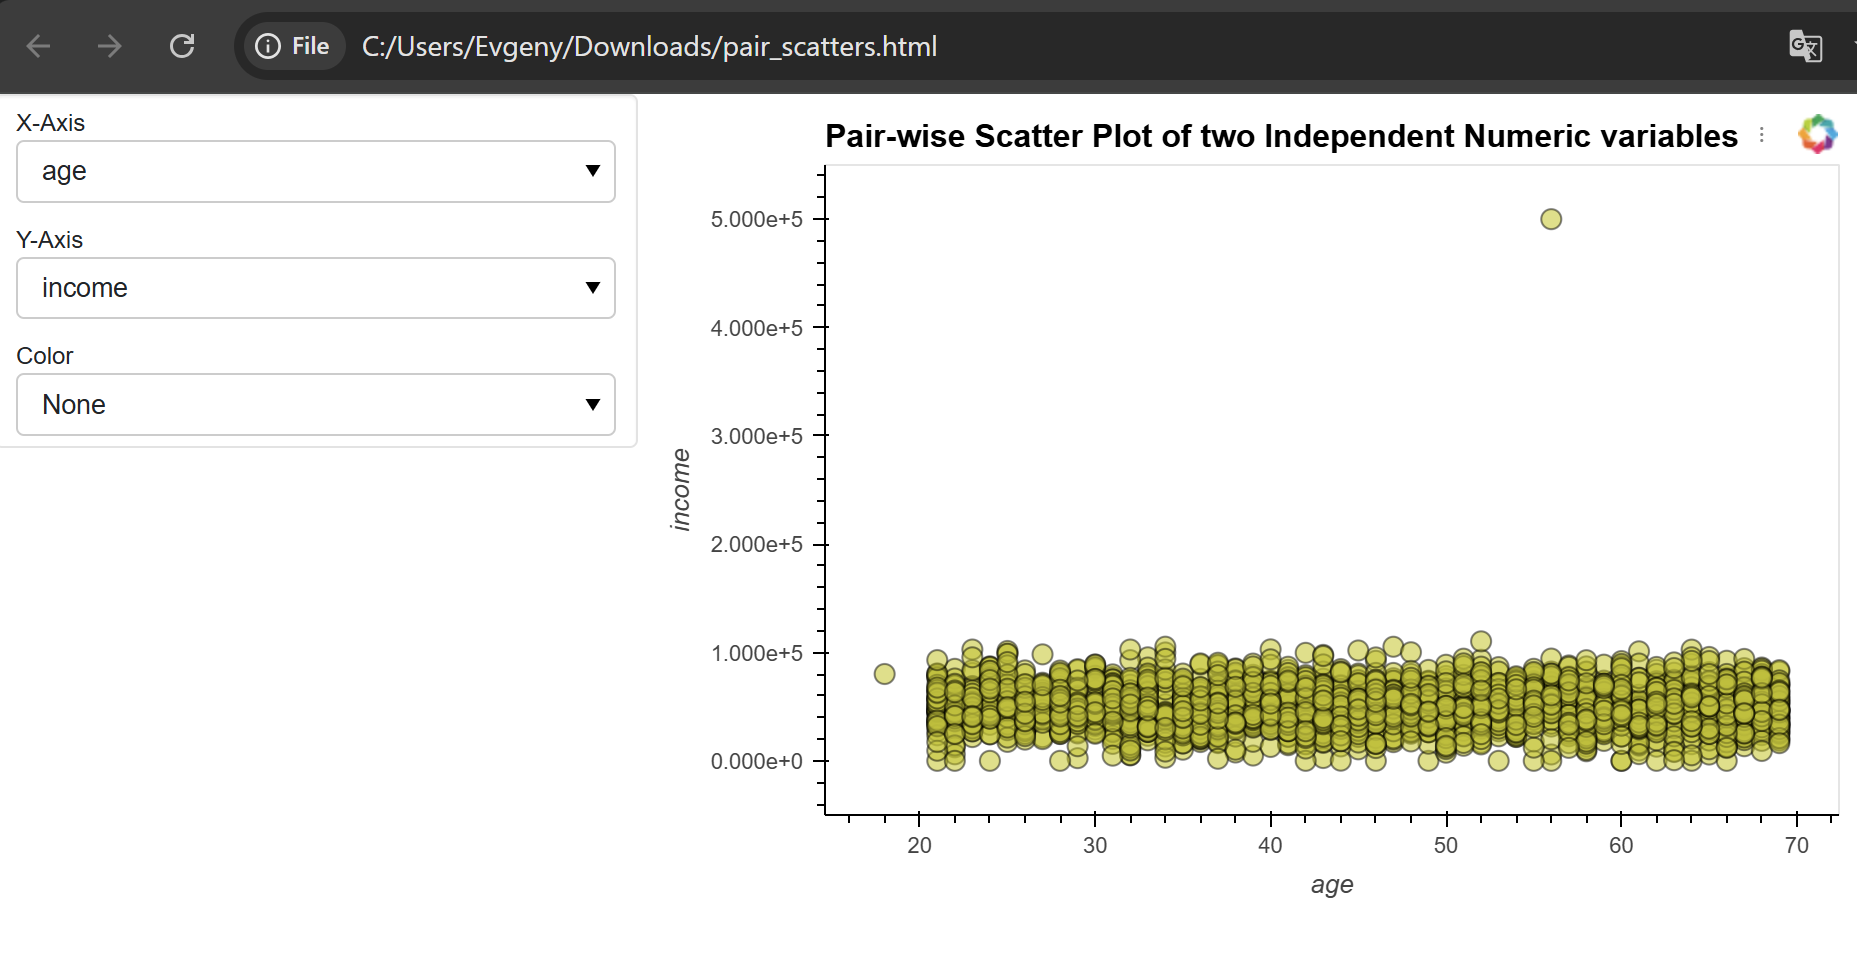

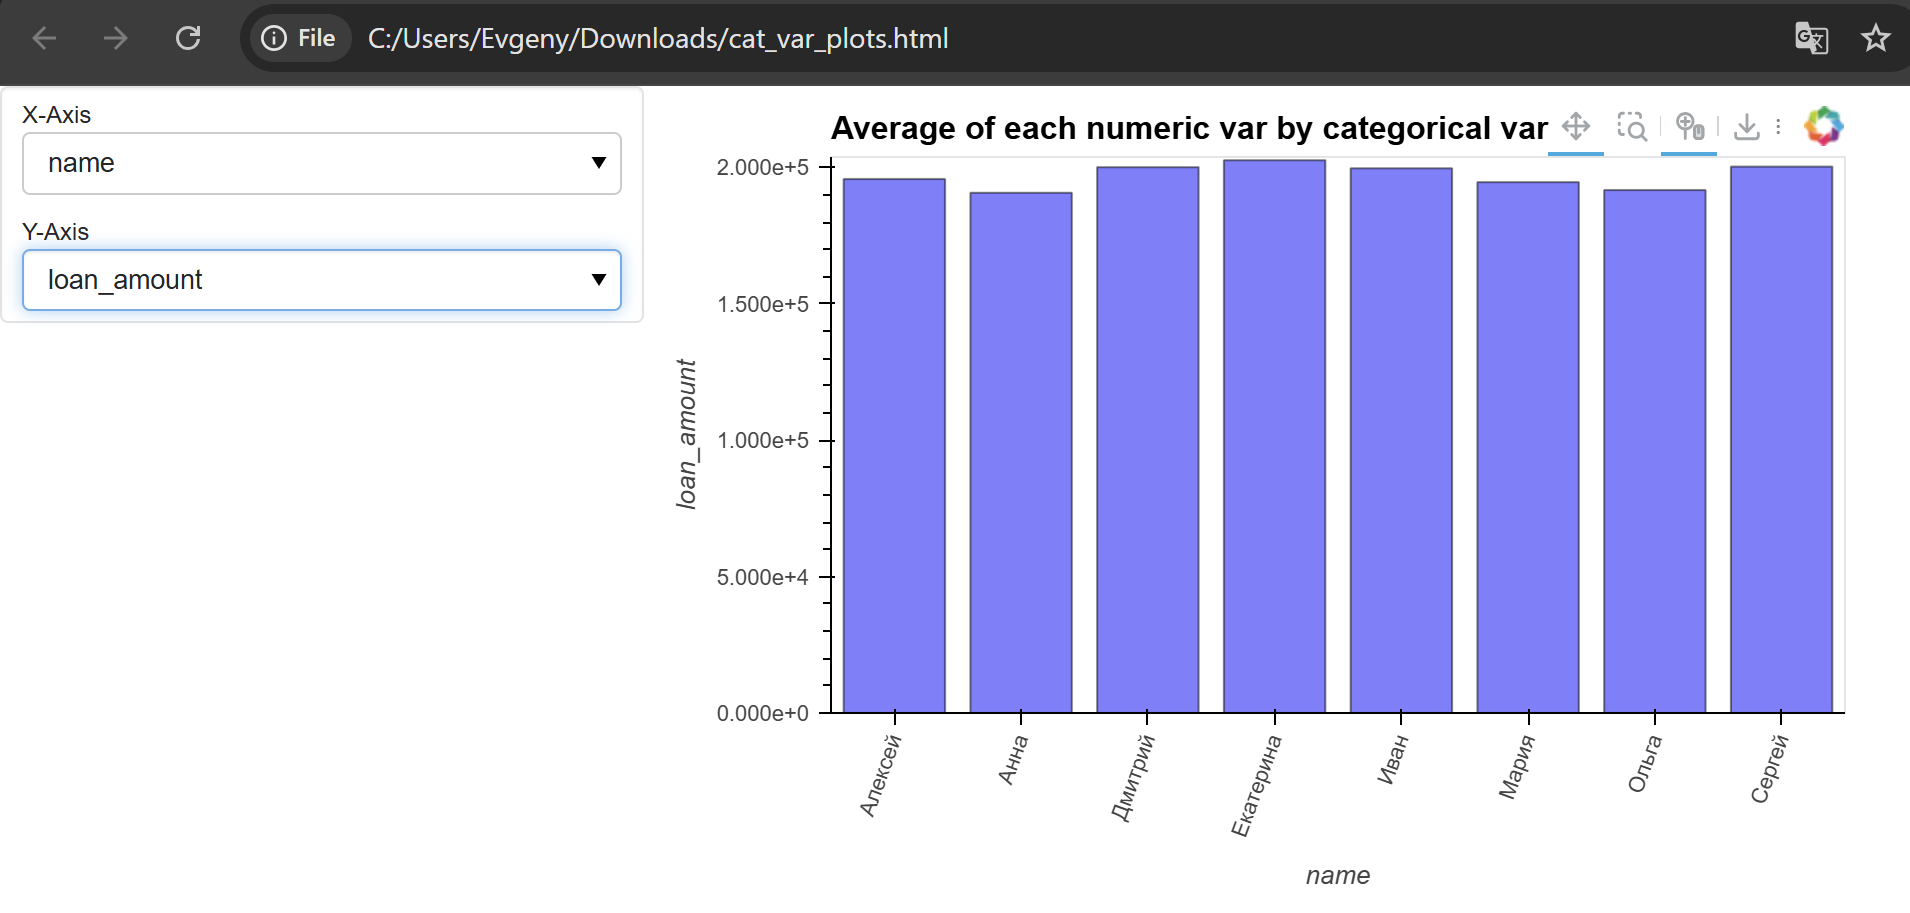

## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Сгенерируй отчёт YData Profiling для сырого датасета с пропусками
   (добавь пару пропусков в df перед генерацией)
2. Сравни с помощью SweetViz клиентов из двух разных городов
3. Запусти AutoViz без указания depVar и посмотри, что изменится
4. Сохрани все отчёты HTML и открой их в браузере

In [ ]:
# пиши свой код и экспериментируй!!! Успехов и креатива!